<a href="https://colab.research.google.com/github/aleksejalex/DYNR1cv_2026/blob/main/DYNR1cv_05_sarsa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DYNR1cv - SARSA.

Prepared by: *Aleksej Gaj* ([email](mailto:aleksejalex@gmail.com))




(**SARSA** stands for **State-Action-Reward-State-Action**)



In [ ]:
%%capture
%pip install gymnasium
%pip install pygame

In [ ]:
# imports:
import random
import numpy as np
#import gym  # old package, not maintained anymore
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython import display

## Setup - "the lake has frozen"... (for the last time!)



`Frozen lake` involves crossing a frozen lake from start to goal without falling into any holes by walking over
the frozen lake.

The player may not always move in the intended direction due to the slippery nature of the
frozen lake.

[official documentation](https://gymnasium.farama.org/environments/toy_text/frozen_lake/)

[unoficial tutorial](https://aleksandarhaber.com/installation-and-getting-started-with-openai-gym-and-frozen-lake-environment-reinforcement-learning-tutorial/)



### Formalization:

**Actions**:

| Action  | Description |
|---------|-------------|
| `0`       | Move Left   |
| `1`       | Move Down   |
| `2`       | Move Right  |
| `3`       | Move Up     |

**States**:
`nrows`x`ncols` grid, player’s current position = `current_row * nrows + current_col` (where both the row and col start at 0).

**Starting state**:
 - always state `[0]` (ie. location [0, 0])

**Rewards**:

| Reward  | Description                       |
|---------|-----------------------------------|
| 0       | Frozen surface (Safe)             |
| 1       | Goal (Reach the goal)             |
| 0       | Hole (Fall into a hole)           |

**Terminal state(s)**:
 - goal (`G`) ... "win"
 - any hole (`H`) ... "lose"

**Is slippery?**
 - agent can the the action with p=1/3 and the "orthogonal" actions also with  p = 1/3 each

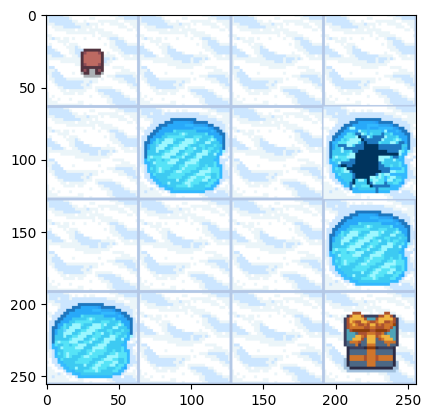

In [ ]:
env = gym.make("FrozenLake-v1", map_name="4x4", render_mode="rgb_array", is_slippery=True)

state=env.reset()[0]
done=False

while not done:
    action=env.action_space.sample()
    new_state, reward, done, info, x = env.step(action)
    img=plt.imshow(env.render())
    display.display(plt.gcf())
    display.clear_output(wait=True)

### Define your custom map:

```
F = firm ice
H = hole in the ice
G = goal
S = starting location
```

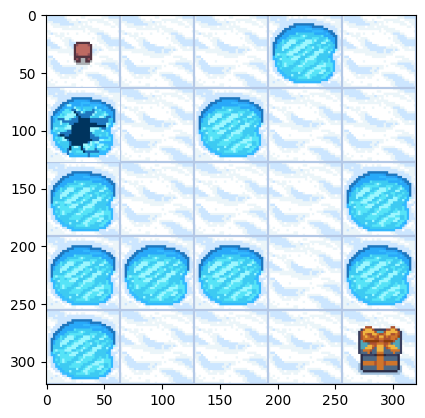

In [ ]:
custom_map = [
    'SFFHF',
    'HFHFF',
    'HFFFH',
    'HHHFH',
    'HFFFG'
]

env = gym.make("FrozenLake-v1", desc=custom_map, render_mode="rgb_array", is_slippery=False)

state=env.reset()[0]
done=False

while not done:
    action=env.action_space.sample()
    new_state, reward, done, info, x = env.step(action)
    img=plt.imshow(env.render())
    display.display(plt.gcf())
    display.clear_output(wait=True)

Now we have working environment to test and visualize the algorithm.

## SARSA - a little of theory to remind

### The Basic Idea

* **Definition**: An **on-policy** Temporal Difference (TD) control algorithm used to estimate the value of an optimal policy.
* SARSA is Model-Free; it doesn't know the probabilities of what could happen (no model)
* **Name Origin**: The acronym stands for the sequence of updates it uses: **S**tate, **A**ction, **R**eward, **S**tate, **A**ction ($S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1}$).
* **On-Policy Nature**: It updates the action-value function $Q(s, a)$ based on the actual action executed by the current policy (typically $\epsilon$-greedy), rather than assuming the optimal action will be taken.

### The formula

The state-action value function is updated at each step using the following equation:


$$
\underbrace{Q(S_t, A_t)}_{\text{New Estimate}} \leftarrow \underbrace{Q(S_t, A_t)}_{\text{Old Estimate}} + \underbrace{\alpha}_{\text{Learning Rate}} [ \underbrace{\overbrace{R_{t+1} + \gamma Q(S_{t+1}, A_{t+1})}^{\text{TD Target (Where we think we are heading)}} - \overbrace{Q(S_t, A_t)}^{\text{Old Estimate}}}_{\text{TD Error (The "Surprise" or Correction Factor)}} ]
$$

* $\alpha$: Learning rate ($0 < \alpha \le 1$)
* $\gamma$: Discount factor ($0 \le \gamma \le 1$)

#### 🔍 Breakdown of Terms:

* **$Q(S_t, A_t)$ (Old Estimate)**: What we *originally thought* the value of taking action $A_t$ in state $S_t$ was before observing the environment's response.
* **$R_{t+1} + \gamma Q(S_{t+1}, A_{t+1})$ (TD Target)**: Our *new, updated guess* of the total future value. It combines the immediate concrete reward ($R_{t+1}$) with the discounted expected value ($\gamma Q$) of the actual next state-action pair we transitioned into.
* **$[ \text{Target} - \text{Old Estimate} ]$ (TD Error)**: The **"surprise"** factor.
  * If this value is **positive**, the outcome was *better* than expected, so we adjust our value estimate upward.
  * If this value is **negative**, the outcome was *worse* than expected, so we adjust our value estimate downward.
* **$\alpha$ (Learning Rate)**: Controls how much weight we give to the new experience. A small $\alpha$ adjusts the estimate conservatively, while an $\alpha$ close to $1$ completely replaces old knowledge with the newest observation.



#### 🧠 Why no mean value present in the formula?

* **No Expectations/Means:** Instead of calculating a mathematical average of all possible future paths (which requires knowing the environment's hidden rules), SARSA uses a single **actual sample** of the future.
* **The Law of Large Numbers:** By running thousands of episodes, the algorithm naturally visits states and actions repeatedly. Over time, these individual transitions naturally "average out" the Q-values to their true expected values without ever needing a model of the world.

### 🛠️ Algorithm

1. Initialize $Q(s, a)$ arbitrarily for all states and actions (and $Q(\text{terminal}, \cdot) = 0$).
2. **Loop for each episode**:
    * Initialize state $S$.
    * Choose action $A$ from state $S$ using policy derived from $Q$ (e.g., $\epsilon$-greedy).
    * **Loop for each step of episode**:
        * Take action $A$, observe reward $R$ and next state $S'$.
        * Choose next action $A'$ from state $S'$ using policy derived from $Q$ (e.g., $\epsilon$-greedy).
        * $Q(S, A) \leftarrow Q(S, A) + \alpha \left[ R + \gamma Q(S', A') - Q(S, A) \right]$
        * $S \leftarrow S'$; $A \leftarrow A'$;
    * **Until** $S$ is terminal.

## SARSA - the code

In [ ]:
env = gym.make("FrozenLake-v1", map_name="4x4", render_mode="rgb_array", is_slippery=True)

In [ ]:
n_states = env.observation_space.n
n_actions = env.action_space.n

In [ ]:
print(f" num of states:{n_states}\n num of actions:{n_actions}")

 num of states:16
 num of actions:4


In [ ]:
Q = np.zeros([n_states,n_actions])
Q.shape

(16, 4)

In [ ]:
Q

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

Constant vars:

In [ ]:
episodes = 20000
alpha = 0.1  # learning rate
gamma = 0.99
G = 0   # G is sum of rewards
epsilon = 1.0  # Prob(take random action)
min_epsilon = 0.01
max_epsilon = 1
decay_rate = 0.001

$\epsilon = \left( \epsilon_{max} - \epsilon_{min}\right) e^{-decayrate \: \cdot \: episode}$

In [ ]:
print("Epsilon not in [0,1] !") if epsilon > 1 or epsilon < 0 else print('')
print("aplha not in [0,1] !") if alpha > 1 or alpha < 0 else print('')

In [ ]:
reward_100 = 0
rewards_100 = []
epsilons = []

Training loop:

In [ ]:
for episode in range(1, episodes+1):
    state = env.reset()[0]
    done = False
    G = 0  # total reward of the episode
    while not done:
        if random.random() < epsilon:
            #random seed is less than epsilon, take random action
            action = env.action_space.sample()
        else:
            #take optimal action
            action = np.argmax(Q[state])

        new_state, reward, done, _, _ = env.step(action)
        new_action = np.argmax(Q[new_state])  # THE DIFFERENCE 1
        Q[state, action] += alpha*(reward + gamma*(Q[new_state, new_action]) - Q[state,action]) # THE DIFFERENCE 2
        G = G + reward
        state = new_state
    reward_100 = reward_100 + G

    # Reduce epsilon (because we need less and less exploration)
    epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*episode)
    epsilons.append(epsilon)

    if episode%100 == 0:
        print(f"Episode {episode}/{episodes}, mean reward: {reward_100 / 100}.")
        rewards_100.append(reward_100)
        reward_100 = 0

Episode 100/20000, mean reward: 0.01.
Episode 200/20000, mean reward: 0.03.
Episode 300/20000, mean reward: 0.04.
Episode 400/20000, mean reward: 0.05.
Episode 500/20000, mean reward: 0.05.
Episode 600/20000, mean reward: 0.07.
Episode 700/20000, mean reward: 0.05.
Episode 800/20000, mean reward: 0.06.
Episode 900/20000, mean reward: 0.07.
Episode 1000/20000, mean reward: 0.1.
Episode 1100/20000, mean reward: 0.19.
Episode 1200/20000, mean reward: 0.17.
Episode 1300/20000, mean reward: 0.19.
Episode 1400/20000, mean reward: 0.12.
Episode 1500/20000, mean reward: 0.24.
Episode 1600/20000, mean reward: 0.21.
Episode 1700/20000, mean reward: 0.23.
Episode 1800/20000, mean reward: 0.19.
Episode 1900/20000, mean reward: 0.3.
Episode 2000/20000, mean reward: 0.34.
Episode 2100/20000, mean reward: 0.37.
Episode 2200/20000, mean reward: 0.28.
Episode 2300/20000, mean reward: 0.44.
Episode 2400/20000, mean reward: 0.44.
Episode 2500/20000, mean reward: 0.42.
Episode 2600/20000, mean reward: 0.3

How rewards look like?

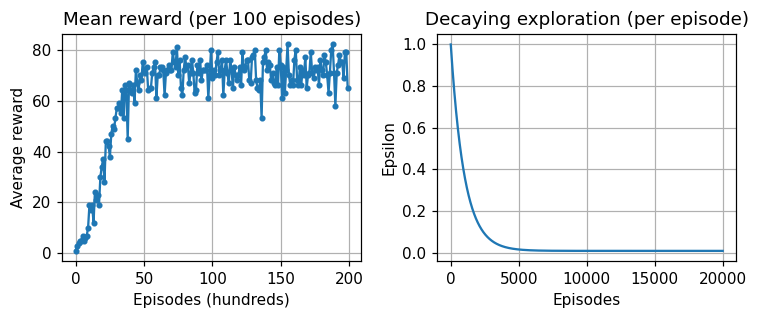

In [ ]:
plt.figure(figsize=(7,3), dpi=110)
plt.subplot(1,2,1)
plt.plot(rewards_100, marker='.', linestyle='-')
plt.title("Mean reward (per 100 episodes)")
plt.xlabel("Episodes (hundreds)")
plt.ylabel("Average reward")
plt.grid()
plt.subplot(1,2,2)
plt.plot(epsilons, '-')
plt.title("Decaying exploration (per episode)")
plt.xlabel("Episodes")
plt.ylabel("Epsilon")
plt.grid()
plt.tight_layout()
plt.show()

How Q-table looks now, after training?

In [ ]:
Q

array([[0.49549275, 0.47625773, 0.48163536, 0.48359631],
       [0.28347213, 0.27532234, 0.25491715, 0.44495899],
       [0.41022752, 0.25512628, 0.27711365, 0.28516451],
       [0.14675343, 0.06162687, 0.03952487, 0.06410043],
       [0.51141607, 0.42688412, 0.31607185, 0.4161663 ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.4252397 , 0.08798382, 0.17040401, 0.14621704],
       [0.        , 0.        , 0.        , 0.        ],
       [0.4794455 , 0.43760007, 0.43641001, 0.55490249],
       [0.36537211, 0.62141929, 0.3331479 , 0.45807591],
       [0.65304241, 0.39593315, 0.33155232, 0.35934045],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.50324523, 0.58289499, 0.6869104 , 0.49079098],
       [0.74726027, 0.74545197, 0.78957093, 0.74688863],
       [0.        , 0.        , 0.        , 0.        ]])

## Simulation

In [ ]:
state=env.reset()[0]
done=False

In [ ]:
rnd_act = 0
num_of_steps = 0

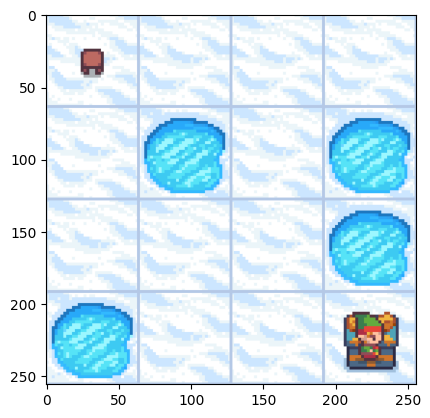

In [ ]:
while not done:
    action = np.argmax(Q[state])
    new_state, reward, done, _, _ = env.step(action)

    img = plt.imshow(env.render())
    display.display(plt.gcf())
    display.clear_output(wait=True)

    state=new_state
    num_of_steps = num_of_steps + 1

In [ ]:
print(f"Elf made {num_of_steps} steps in total.")

Elf made 33 steps in total.
